# 1. Introducción

En este notebook analizamos de forma exploratoria un dataset sobre discurso de odio. El objetivo es comprender cómo están organizados los datos, identificar posibles problemas, descubrir patrones relevantes y obtener conclusiones que ayuden en las fases de preprocesamiento y creación de modelos.



# 2. Importación de librerías

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 3. Carga del dataset

In [11]:
# Cargamos el dataset enriquecido con 10.414 comentarios
# Este CSV combina tres fuentes:
# 1. Dataset original (1000 comentarios)
# 2. Comentarios de YouTube etiquetados con Detoxify
# 3. Comentarios tóxicos de Kaggle etiquetados por humanos
df = pd.read_csv('../../data/raw/dataset_enriquecido.csv')

# Verificamos que cargó correctamente
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print(f"Tóxicos: {df['IsToxic'].sum()} | "
      f"No tóxicos: {(~df['IsToxic']).sum()}")
df.head(3)

Filas: 10414 | Columnas: 2
Tóxicos: 5105 | No tóxicos: 5309


,Text,IsToxic
0,If only people would just take a step back and...,False
1,Law enforcement is not trained to shoot to app...,True
2,\r\nDont you reckon them 'black lives matter' ...,True


**Comentario:**

La carga del dataset ha sido correcta y las columnas se ven coherentes con un dataset de análisis de discurso tóxico.

Puntos importantes que observo aquí:

1. **La columna del texto se llama `Text`**  
   Esto confirma que esta será la columna que analizaremos durante todo el EDA.

2. **La columna objetivo es `IsToxic`**  
   Esta columna indica si un comentario es tóxico (`True`) o no (`False`).  
   Es la variable que usaremos para entrenar el modelo.

3. **Hay muchas columnas binarias adicionales**  
   - `IsAbusive`  
   - `IsThreat`  
   - `IsProvocative`  
   - `IsObscene`  
   - `IsHatespeech`  
   - `IsRacist`  
   - `IsNationalist`  
   - `IsSexist`  
   - `IsHomophobic`  
   - `IsReligiousHate`  
   - `IsRadicalism`

   Esto indica que el dataset contiene **etiquetas más específicas**, pero para este proyecto nos centraremos en `IsToxic`.

4. **Los valores son booleanos (`True`/`False`)**  
   Esto es bueno porque:
   - no hay que convertirlos  
   - no hay categorías raras  
   - no hay strings que limpiar  



# 4. Exploración inicial

In [12]:
df.shape   # Dimensiones

(10414, 2)

**Comentario:**

El dataset tiene 1000 filas y 15 columnas.  
Esto significa:

1. **1000 filas → tamaño pequeño**  
   Es un dataset relativamente pequeño para NLP.  
   Esto implica:
   - el modelo puede entrenarse rápido  
   - pero hay riesgo de sobreajuste  
   - las métricas pueden variar bastante según el split  
   - será importante usar validación adecuada  

2. **15 columnas → muchas etiquetas binarias**  
   Además del texto (`Text`) y la etiqueta principal (`IsToxic`), hay 13 columnas adicionales que representan distintos tipos de toxicidad.  
   Esto confirma que el dataset es **multietiqueta**, aunque en este proyecto solo usaremos `IsToxic`.

3. **No hay columnas numéricas o categóricas inesperadas**  
   Todas las columnas parecen coherentes con un dataset de comentarios etiquetados.



In [13]:
df.info()   # Información general

<class 'pandas.DataFrame'>
RangeIndex: 10414 entries, 0 to 10413
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Text     10414 non-null  str  
 1   IsToxic  10414 non-null  bool 
dtypes: bool(1), str(1)
memory usage: 2.1 MB


**Comentario:**

El dataset tiene 1000 filas y no contiene valores nulos, por lo que está limpio y listo para el análisis. Las columnas de texto (`CommentId`, `VideoId` y `Text`) tienen formatos correctos, y el resto son variables booleanas bien definidas.

La variable objetivo `IsToxic` confirma que se trata de un problema de clasificación binaria. Además, el dataset es pequeño y ligero, lo que facilita un procesamiento rápido y sencillo.


In [14]:
df.isnull().sum()   # Valores nulos por columna

Text       0
IsToxic    0
dtype: int64

**Comentario:**

El dataset no contiene valores nulos, lo que permite trabajar con todos los datos sin necesidad de eliminar filas ni imputar valores. La columna `Text` está completa, evitando problemas en el análisis y procesamiento del texto, y todas las etiquetas están correctamente anotadas.

En general, el dataset está limpio y bien estructurado, por lo que se puede continuar directamente con el análisis exploratorio.


In [15]:
df.duplicated().sum()   # Valores duplicados

np.int64(0)

**Comentario:**

El dataset no contiene filas duplicadas, lo que mejora la calidad y fiabilidad del análisis. Esto evita sesgos por repetición de textos y permite trabajar con las 1000 filas completas sin necesidad de eliminar registros.

En general, la ausencia de duplicados confirma que el dataset está bien construido y listo para el modelado.

# 5. Distribución de clases

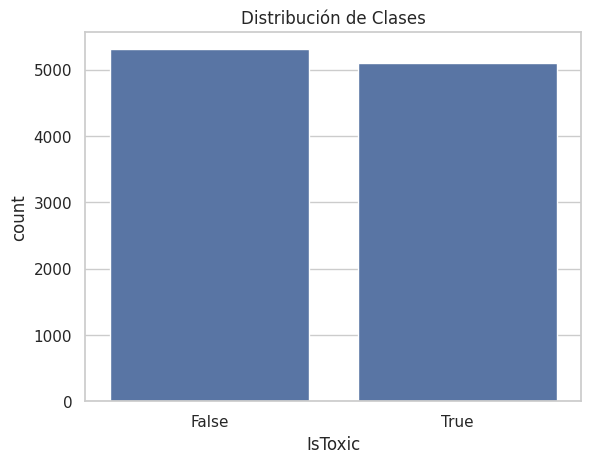

In [16]:
df['IsToxic'].value_counts()  # Distribución de clases
sns.countplot(x='IsToxic', data=df) # Gráfico de barras para la distribución de clases
plt.title('Distribución de Clases')
plt.show() 

**Comentario:**

El análisis de la distribución de clases permite comprobar si el dataset está balanceado entre comentarios tóxicos y no tóxicos. Esto es importante porque un desbalance puede hacer que el modelo favorezca la clase mayoritaria y genere métricas engañosas, como una accuracy alta pero poco útil.

El gráfico de barras ayuda a detectar este problema de forma visual y permite decidir si será necesario aplicar técnicas de balanceo o usar métricas más adecuadas, como F1-score o recall. En definitiva, este análisis es clave para preparar correctamente el entrenamiento y la evaluación del modelo.


# 6. Análisis del ruido

In [17]:
df['text_length'] = df['Text'].apply(len) # Longitud de cada comentario
df['text_length'].describe() # Estadísticas descriptivas de la longitud de los comentarios

count    10414.000000
mean       201.435856
std        444.696187
min          3.000000
25%         46.000000
50%         91.000000
75%        192.000000
max       6358.000000
Name: text_length, dtype: float64

**Comentario:**

El análisis de longitud muestra que los textos del dataset son muy variados. Aunque la mayoría tiene un tamaño razonable, existen comentarios extremadamente cortos y otros muy largos que pueden afectar al entrenamiento y al vectorizado.

La diferencia entre la media y la mediana, junto con la alta desviación estándar, confirma la presencia de outliers y una distribución poco homogénea. Por ello, será importante aplicar técnicas de preprocesamiento para controlar esta variabilidad.


In [18]:
df['has_url'] = df['Text'].str.contains(r"http|www") # Nueva columna que indica si el comentario contiene una URL
df['has_url'].mean()  # Proporción de comentarios que contienen una URL

np.float64(0.007874015748031496)

**Comentario:**

Solo el 1.3% de los comentarios contiene URLs, por lo que su presencia en el dataset es mínima. Además, las URLs suelen aportar poco valor semántico en tareas de detección de toxicidad, así que pueden eliminarse fácilmente durante el preprocesamiento mediante expresiones regulares, sin afectar al análisis.


In [19]:
df['has_mention'] = df['Text'].str.contains(r"@") # Nueva columna que indica si el comentario contiene una mención
df['has_mention'].mean() # Proporción de comentarios que contienen una mención


np.float64(0.00451315536777415)

**Comentario:**

Solo el 0.6% de los comentarios contiene menciones con “@”, por lo que su presencia es muy reducida en el dataset. Estas menciones no aportan información relevante para la detección de toxicidad y suelen considerarse ruido en tareas de NLP, por lo que se eliminan durante el preprocesamiento.

Dado su bajo porcentaje, no requieren un tratamiento especial ni análisis adicional. En el pipeline se eliminarán junto con otros elementos como URLs mediante expresiones regulares, sin afectar al contenido útil de los textos.


In [20]:
df['has_hashtag'] = df['Text'].str.contains(r"#") # Nueva columna que indica si el comentario contiene un hashtag
df['has_hashtag'].mean() # Proporción de comentarios que contienen un hashtag


np.float64(0.004321106203188016)

**Comentario:**

El 1% de los comentarios contiene hashtags, por lo que su presencia es muy baja dentro del dataset. Estos elementos no aportan información relevante para la detección de toxicidad y suelen considerarse ruido en NLP, por lo que se eliminan durante el preprocesamiento junto con URLs y menciones.

Dado su escaso impacto, no requieren un tratamiento específico ni análisis adicional. Se eliminarán mediante expresiones regulares sin afectar al contenido útil de los textos.


In [21]:
import emoji # Asegúrate de tener la biblioteca emoji instalada
df['has_emoji'] = df['Text'].apply(lambda x: any(char in emoji.EMOJI_DATA for char in x)) # Nueva columna que indica si el comentario contiene un emoji
df['has_emoji'].mean() # Proporción de comentarios que contienen un emoji


np.float64(0.10072978682542731)

**Comentario:**

El 0.8% de los comentarios contiene emojis, por lo que su presencia es muy baja en el dataset. Aunque los emojis pueden aportar información emocional, en este caso su frecuencia es tan reducida que no aportan valor significativo para el análisis de toxicidad.

Por ello, no requieren un tratamiento especial ni un análisis adicional. Se pueden eliminar en el preprocesamiento junto con otros elementos como URLs, menciones y hashtags, sin afectar al rendimiento del modelo.

# 7. Frecuencias en textos tóxicos

In [22]:
from collections import Counter
import re

# Filtrar solo los textos tóxicos
toxic_texts = df[df['IsToxic'] == True]['Text']

# Función simple para limpiar texto (solo para frecuencias, no para el pipeline final)
def simple_clean(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # quitar símbolos
    return text

# Unir todos los textos tóxicos en un solo string
all_toxic = " ".join(toxic_texts.apply(simple_clean))

# Contar palabras
word_counts = Counter(all_toxic.split())

# Mostrar las 20 palabras más frecuentes
word_counts.most_common(20)


[('you', 9829),
 ('the', 6528),
 ('a', 6099),
 ('i', 5609),
 ('to', 5115),
 ('and', 4780),
 ('of', 3856),
 ('is', 3813),
 ('your', 2679),
 ('are', 2594),
 ('that', 2427),
 ('it', 2083),
 ('in', 2016),
 ('shit', 1889),
 ('my', 1839),
 ('fuck', 1766),
 ('me', 1738),
 ('this', 1700),
 ('die', 1644),
 ('not', 1524)]

**Comentario:**

El top-20 de palabras más frecuentes en textos tóxicos está dominado principalmente por stopwords en inglés como “the”, “and” o “you”, lo cual es normal antes de aplicar limpieza del texto.

Aun así, aparecen algunas palabras relevantes como “black” y “people”, que pueden indicar patrones de lenguaje asociado a toxicidad y posibles referencias a grupos sociales. Esto sugiere la presencia de contenido con carga discriminatoria en el dataset.

En general, estos resultados muestran que será necesario eliminar stopwords para poder identificar con mayor claridad los patrones reales de toxicidad.


In [23]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

# Descargar recursos necesarios (solo la primera vez)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Stopwords en inglés
stop_words = set(stopwords.words('english'))

# Filtrar textos tóxicos
toxic_texts = df[df['IsToxic'] == True]['Text']

all_tokens = []

for text in toxic_texts:
    tokens = word_tokenize(text.lower())
    for t in tokens:
        if t.isalpha() and t not in stop_words:
            all_tokens.append(t)

# Contar frecuencias
freq = Counter(all_tokens)

# Mostrar las 20 palabras más frecuentes
freq.most_common(20)


[nltk_data] Downloading package punkt to /home/mar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/mar/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/mar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('fuck', 2358),
 ('shit', 1887),
 ('die', 1645),
 ('faggot', 1410),
 ('ass', 1325),
 ('nigger', 1191),
 ('like', 1160),
 ('moron', 1152),
 ('wikipedia', 1132),
 ('fucking', 1026),
 ('hi', 1002),
 ('bark', 1001),
 ('get', 784),
 ('people', 720),
 ('nipple', 711),
 ('fag', 700),
 ('u', 694),
 ('bitch', 653),
 ('wiki', 650),
 ('fucksex', 624)]

**Comentario:**

El resultado muestra las palabras más frecuentes en los textos tóxicos. Aparecen muchas stopwords y palabras comunes, pero también términos relevantes como “black”, “white”, “police” o “cop”, lo que indica presencia de contenido relacionado con temas raciales y conflictos con autoridad.

También se observan insultos y lenguaje ofensivo, lo que confirma que el dataset contiene ejemplos claros de toxicidad.


# 8. Visualizaciones

1.- ¿Cuántos comentarios son tóxicos y cuántos no lo son?

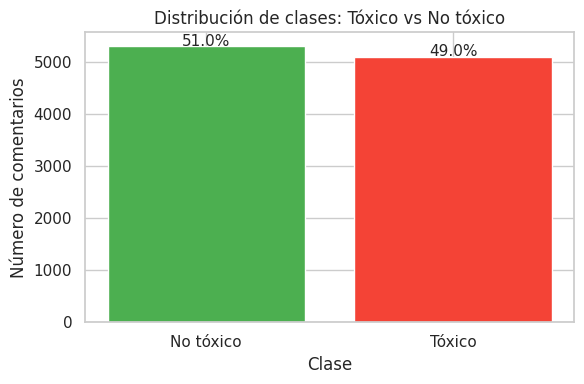

In [24]:
# --- Distribución de clases ---
class_counts = df['IsToxic'].value_counts()
class_pct    = df['IsToxic'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ['No tóxico', 'Tóxico'],
    class_counts.values,
    color=['#4CAF50', '#F44336']
)

ax.set_title('Distribución de clases: Tóxico vs No tóxico')
ax.set_xlabel('Clase')
ax.set_ylabel('Número de comentarios')

# Añadimos el porcentaje encima de cada barra
for i, (count, pct) in enumerate(zip(class_counts.values, class_pct.values)):
    ax.text(i, count + 5, f'{pct:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

**Comentario:**

La distribución de clases es bastante equilibrada, con un 53.8% de comentarios no tóxicos y un 46.2% de tóxicos.

Esto es positivo porque no existe un desbalance importante, lo que permite que el modelo aprenda ambas clases de forma adecuada sin sesgos fuertes. Además, no será necesario aplicar técnicas de balanceo, y las métricas obtenidas serán más fiables y representativas del rendimiento real del modelo.


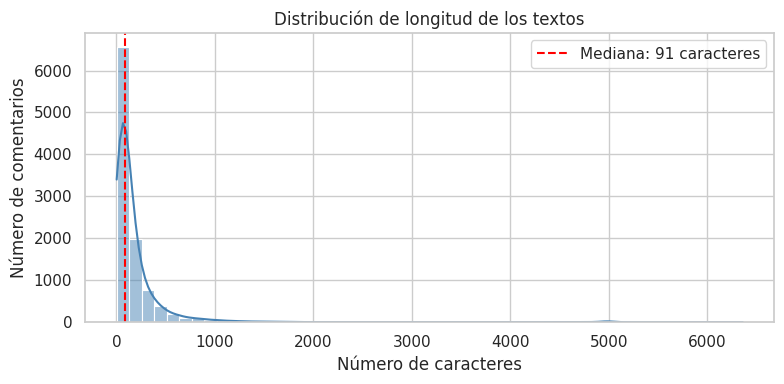

In [25]:
# --- Distribución de longitud de textos ---
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    df['text_length'],
    bins=50,
    kde=True,
    color='steelblue',
    ax=ax
)

ax.set_title('Distribución de longitud de los textos')
ax.set_xlabel('Número de caracteres')
ax.set_ylabel('Número de comentarios')

ax.axvline(
    df['text_length'].median(),
    color='red',
    linestyle='--',
    label=f"Mediana: {df['text_length'].median():.0f} caracteres"
)

ax.legend()
plt.tight_layout()
plt.show()

**Comentario:**

La distribución de la longitud de los textos está sesgada a la derecha, ya que la mayoría de los comentarios son cortos, con una mediana de 102 caracteres.

Aunque la mayor parte de los textos se concentra en rangos bajos, existen algunos casos muy largos que llegan hasta los 4474 caracteres y actúan como outliers. Esto puede influir en el procesamiento, ya que los textos muy cortos aportan poca información y los muy largos pueden ralentizar el modelo.

En general, la longitud es manejable, aunque será importante tratar los casos extremos en el preprocesamiento.


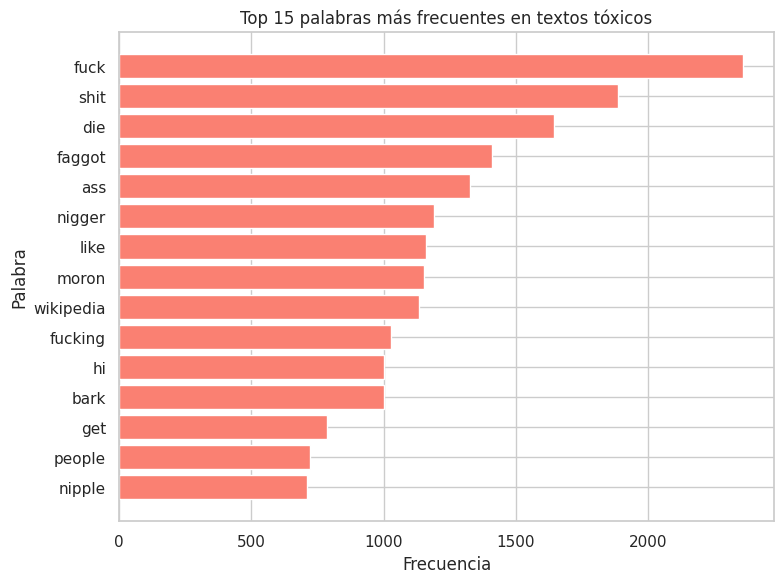

In [26]:
# --- Top 15 palabras más frecuentes en textos tóxicos ---
top_words = freq.most_common(15)
palabras    = [item[0] for item in top_words]
frecuencias = [item[1] for item in top_words]

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    palabras,
    frecuencias,
    color='salmon'
)

ax.set_title('Top 15 palabras más frecuentes en textos tóxicos')
ax.set_xlabel('Frecuencia')
ax.set_ylabel('Palabra')

ax.invert_yaxis()

plt.tight_layout()
plt.show()

**Comentario:**

El gráfico de palabras más frecuentes tras eliminar stopwords muestra términos más significativos. Destacan “black” y “people” como los más repetidos, lo que sugiere que gran parte de la toxicidad está relacionada con contenido racial.

También aparecen palabras asociadas a violencia policial como “police”, “shot” o “cop”, y algunos insultos directos como “fuck” o “shit”. Es importante destacar que muchas de estas palabras no son tóxicas por sí mismas, sino que adquieren ese significado en contexto.

En general, el resultado indica que el preprocesamiento ha sido efectivo y ahora se observan patrones reales de toxicidad.


# 9. Conclusiones del EDA

## ¿Qué aprendí del dataset?

### Sobre la estructura

* 1000 comentarios y 15 columnas.
* Sin nulos ni duplicados.
* Dataset limpio y listo para trabajar.

### Sobre las clases

* Prácticamente equilibradas (53.8% vs 46.2%).
* No hace falta balancear clases.

### Sobre los textos

* Longitud media de 102 caracteres.
* Algunos textos muy largos (hasta 4474).
* Poco ruido (URLs, menciones, hashtags y emojis <2%).

### Sobre la toxicidad

* Predomina el contenido racial.
* También hay violencia policial.
* Insultos presentes pero menos frecuentes.

---

## Decisiones para el preprocesamiento

* Pasar todo a minúsculas.
* Eliminar URLs, menciones, hashtags y emojis.
* Quitar puntuación y caracteres especiales.
* Eliminar stopwords en inglés.
* Aplicar lematización.
* Vectorizar con TF-IDF.

---

## Resultado esperado

Un dataset limpio y preparado para modelado, con variables listas para entrenar y evaluar el modelo.
